In [75]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import math
import openpyxl
from pathlib import Path
import datetime
import re
import numpy as np
import pickle


In [76]:
files = os.listdir("classified_datasets/traffic/anpr_excel")
files = [f for f in files if f.endswith(".csv")]
files

['Bath ANPR anonymised data 10th Nov 2017.csv',
 'Bath ANPR anonymised data 11th Nov 2017.csv',
 'Bath ANPR anonymised data 12th Nov 2017.csv',
 'Bath ANPR anonymised data 13th Nov 2017.csv',
 'Bath ANPR anonymised data 1st Nov 2017.csv',
 'Bath ANPR anonymised data 2nd Nov 2017.csv',
 'Bath ANPR anonymised data 31st Oct 2017.csv',
 'Bath ANPR anonymised data 3rd Nov 2017.csv',
 'Bath ANPR anonymised data 4th Nov 2017.csv',
 'Bath ANPR anonymised data 5th Nov 2017.csv',
 'Bath ANPR anonymised data 6th Nov 2017.csv',
 'Bath ANPR anonymised data 7th Nov 2017.csv',
 'Bath ANPR anonymised data 8th Nov 2017.csv']

In [77]:
comb = pd.DataFrame()
for i in files:
    df = pd.read_csv(f"classified_datasets/traffic/anpr_excel/{i}")
    comb = pd.concat([comb, df], ignore_index=True)

In [78]:
comb["timestamp"] = pd.to_datetime(comb["timestamp"])

In [79]:
comb.sort_values("timestamp", inplace=True)
comb.reset_index(drop=True, inplace=True)
comb["Confidence"] = comb["Confidence"].astype(int)
comb.drop(columns=["Unique vehicle reference", "Vehicle Registration Plate", "Country"], inplace=True, errors="ignore")
comb = comb[comb["Confidence"] > 0]
comb.reset_index(drop=True, inplace=True)
comb

,timestamp,Confidence,Site Reference,Direction
0,2017-10-31 00:03:27,100,16,E
1,2017-10-31 00:06:41,100,32,N
2,2017-10-31 00:07:43,99,13,N
3,2017-10-31 00:09:02,99,17,E
4,2017-10-31 00:09:39,30,15,E
...,...,...,...,...
3721239,2017-11-13 23:59:48,99,13,N
3721240,2017-11-13 23:59:54,100,21,S
3721241,2017-11-13 23:59:55,99,7,W
3721242,2017-11-13 23:59:58,100,20,W


In [80]:
sensor_names = pd.read_csv("classified_datasets/traffic/location_names.csv")
sensor_names.drop(columns=["name", "id", "direction"], inplace=True, errors="ignore")
sensor_names.drop_duplicates(subset=['location_id'], inplace=True)
sensor_names.reset_index(drop=True, inplace=True)
comb["sensor_name"] = comb["Site Reference"].map(sensor_names.set_index("location_id")["sensor_name"])
comb["longitude"] = comb["Site Reference"].map(sensor_names.set_index("location_id")["longitude"])
comb["latitude"] = comb["Site Reference"].map(sensor_names.set_index("location_id")["latitude"])
comb["route"] = comb["Site Reference"].map(sensor_names.set_index("location_id")["route"])

comb.drop(columns=["sensor_name", "Confidence"], inplace=True, errors="ignore")

In [81]:
comb.drop(index=comb[comb["Site Reference"] == 33].index, inplace=True, errors="ignore")

In [82]:
by_site_ref = {site_ref: group for site_ref, group in comb.groupby('Site Reference')}
by_direction = {direction: group for direction, group in comb.groupby('Direction')}
by_site_direction = {
    site_ref: {
        direction: dir_group
        for direction, dir_group in site_group.groupby('Direction')
    }
    for site_ref, site_group in comb.groupby('Site Reference')
}
sensor_dic = by_site_direction

In [83]:
sensor_dic

{1: {'N':                   timestamp  Site Reference Direction  longitude   latitude  \
  19      2017-10-31 00:14:07               1         N  -2.394289  51.415472   
  40      2017-10-31 00:15:45               1         N  -2.394289  51.415472   
  187     2017-10-31 00:23:38               1         N  -2.394289  51.415472   
  269     2017-10-31 00:28:28               1         N  -2.394289  51.415472   
  763     2017-10-31 01:04:27               1         N  -2.394289  51.415472   
  ...                     ...             ...       ...        ...        ...   
  3720435 2017-11-13 23:32:29               1         N  -2.394289  51.415472   
  3720718 2017-11-13 23:40:48               1         N  -2.394289  51.415472   
  3720977 2017-11-13 23:49:05               1         N  -2.394289  51.415472   
  3721180 2017-11-13 23:56:44               1         N  -2.394289  51.415472   
  3721195 2017-11-13 23:57:35               1         N  -2.394289  51.415472   
  
           route 

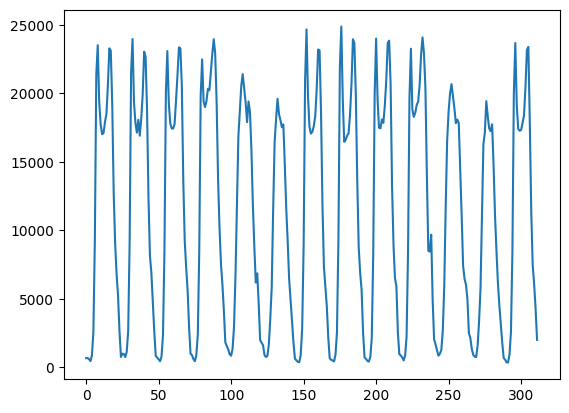

In [84]:
quarterly_count = comb.groupby(comb['timestamp'].dt.floor('1h')).size()

import matplotlib.pyplot as plt
plt.plot(quarterly_count.values)

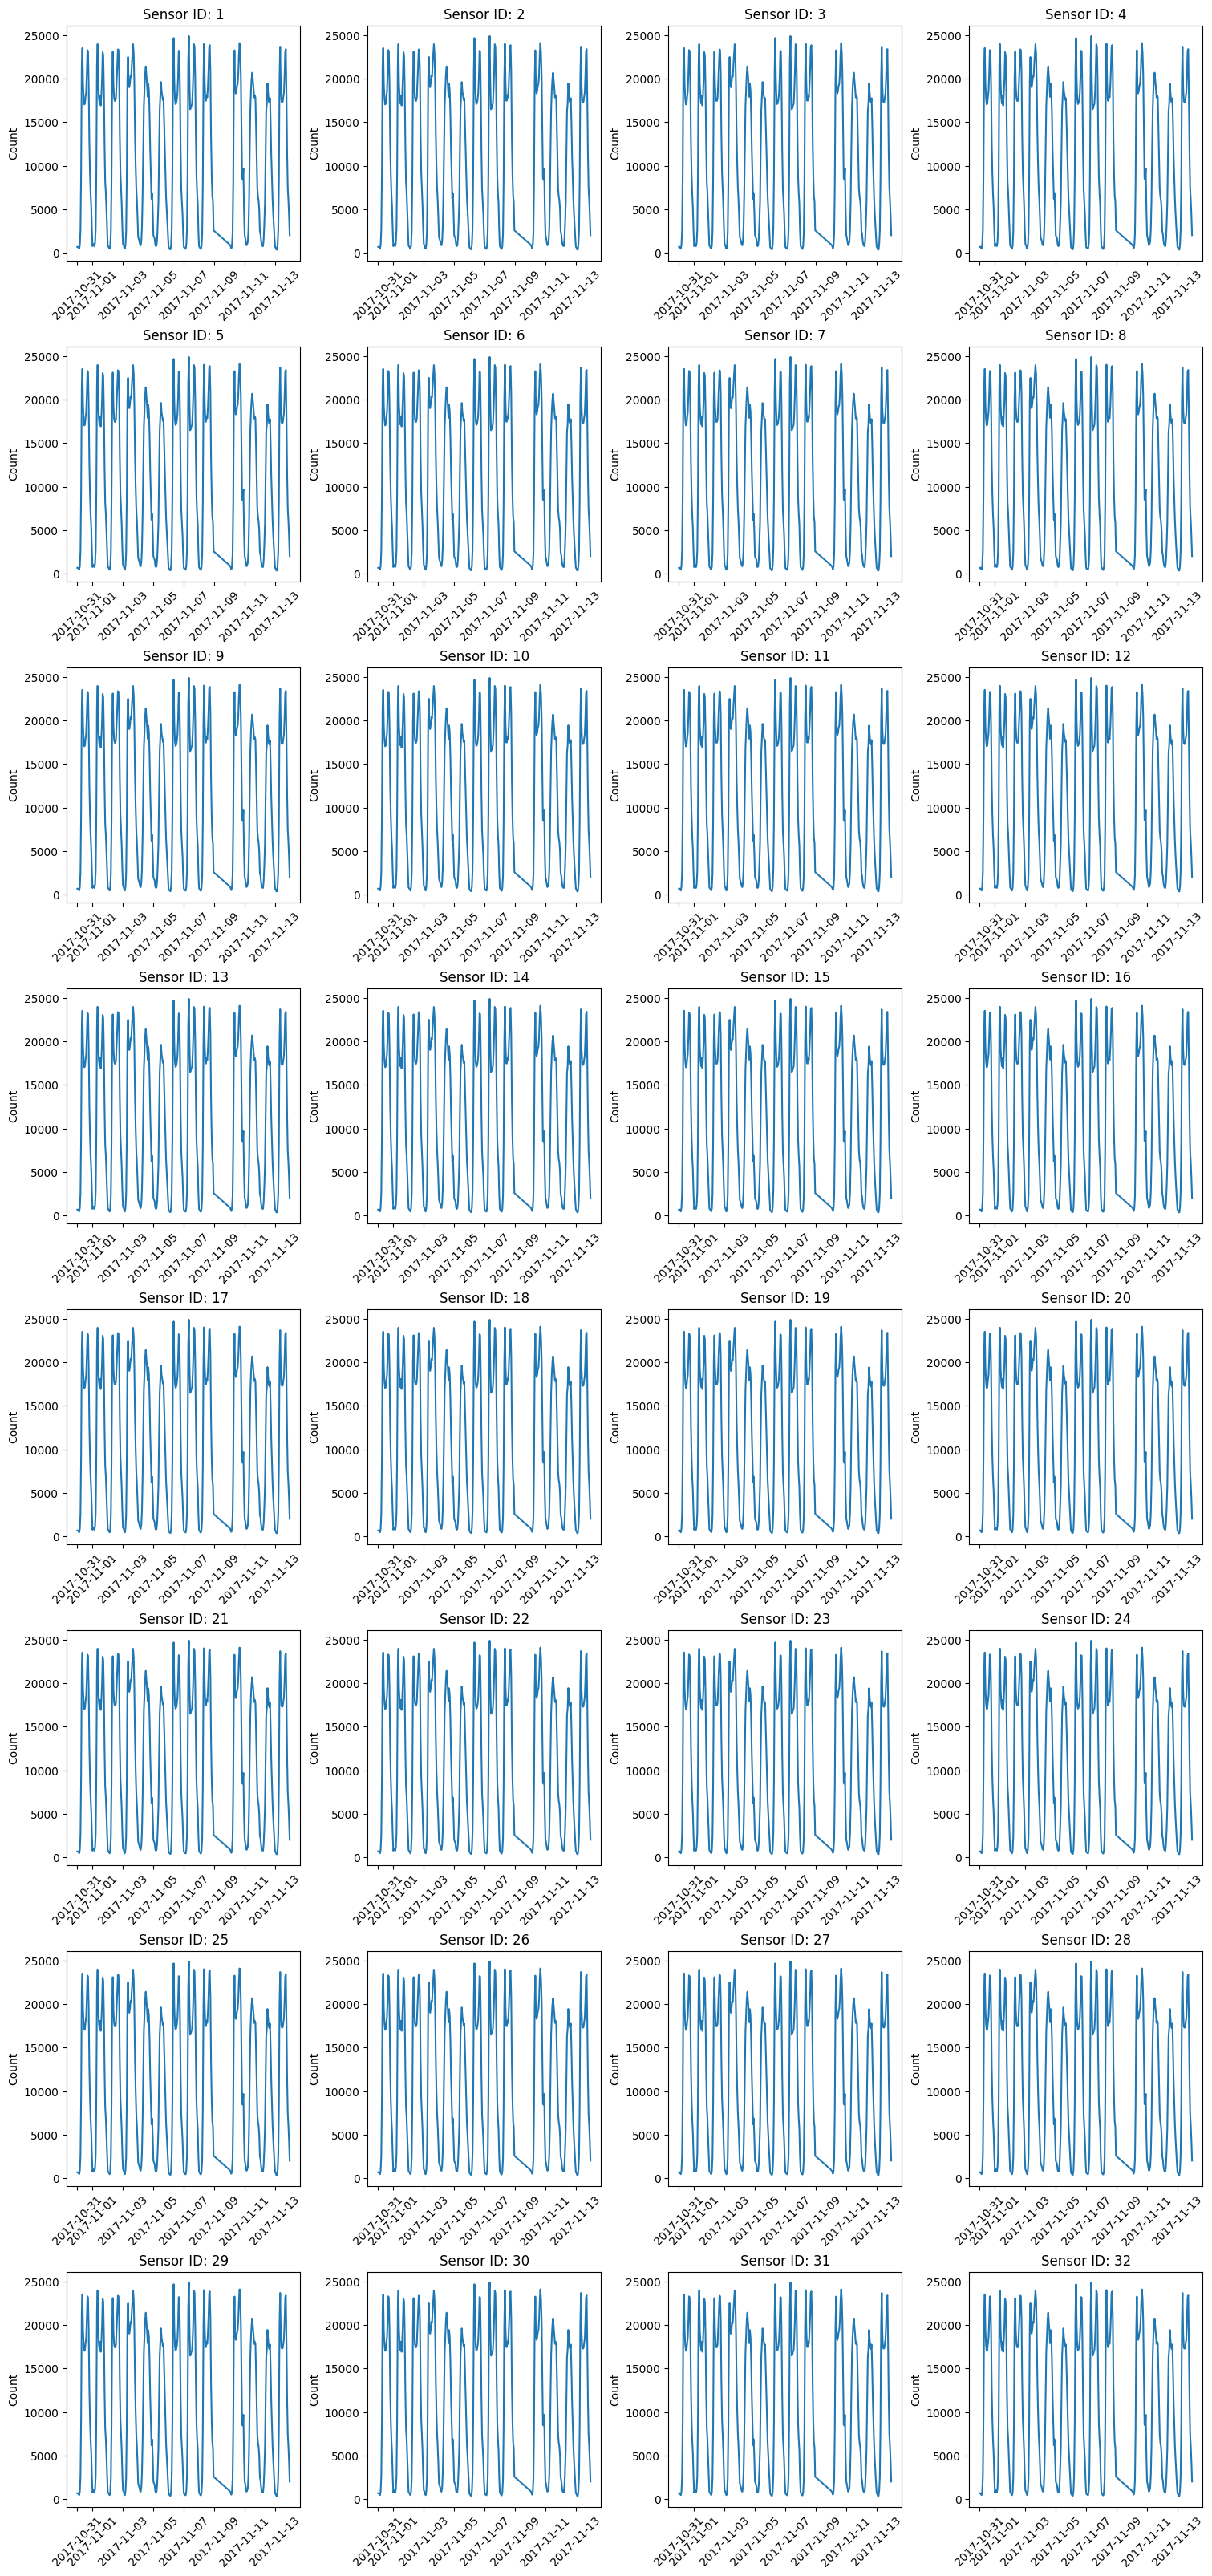

In [85]:
num_sensors = len(by_site_ref)
cols = 4  
rows = math.ceil(num_sensors / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (sensor_id, data) in enumerate(by_site_ref.items()):    
    axes[i].plot(quarterly_count.index, quarterly_count.values)
    axes[i].set_title(f"Sensor ID: {sensor_id}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

# atc data

In [86]:
class ExcelTrafficParser:
    """Parse traffic ATC Excel files with flexible sheet names and counts"""
    
    def __init__(self, filepath):
        self.filepath = filepath
        self.wb = openpyxl.load_workbook(filepath)
        self.site_info = {}
    
    def parse_sheet(self, sheet_name):
        """Parse single sheet, excluding totals"""
        ws = self.wb[sheet_name]
        rows = list(ws.iter_rows(values_only=True))
        headers = rows[5]
        self.direction_first = rows[2][-2][0]
        coordinates = rows[0][-2]
        self.latitude, self.longitude = coordinates.split(",")
        # Exclude last 2 columns (5-Day Av, 7-Day Av)
        if headers:
            headers = headers[:-1]
        
        data = []
        for row in rows[6:]:
            if row[0] is not None:
                clean_row = row[:-1]
                data.append(clean_row)
        df = pd.DataFrame(data, columns=headers)
        df.columns = ['Time'] + [f'Day_{i}' if isinstance(h, datetime.datetime) else str(h) for i, h in enumerate(headers[1:])]
        df['Sheet'] = sheet_name
        return df
    
    def keep_essential_rows(self, df):
        mask = df["Time"].apply(lambda x: isinstance(x, datetime.time))
        df = df[mask].reset_index(drop=True)
        df.drop(columns=[df.columns[-2]], inplace=True)
        return df

    def to_datetime(self, df):
        df["Sheet"] = df["Sheet"].apply(lambda x: x.split()[1:])
        df["Date"] = df["Sheet"].apply(lambda x: datetime.date(int(x[2]), int(x[1]), int(x[0])))
        df["timestamp"] = df.apply(lambda x: datetime.datetime.combine(x["Date"], x["Time"]),axis=1)
        df.drop(columns=["Sheet"], inplace=True)
        return df
    
    def wide_to_long(self, df):
        day_cols = [col for col in df.columns if col.startswith("Day_")]
        df = df.melt(
            id_vars=["timestamp"],
            value_vars=day_cols,
            var_name="horizon",
            value_name="count")
        df["horizon_num"] = df["horizon"].str.extract("(\d+)").astype(int)

        # Add the horizon offset to the timestamp
        df["timestamp"] = df["timestamp"] + pd.to_timedelta(df["horizon_num"], unit="D")

        df.drop(columns=["horizon", "horizon_num"], inplace=True)
        df["direction"] = self.direction_first
        df["latitude"] = self.latitude
        df["longitude"] = self.longitude
        return df

    def remove_totals(self, df):
        # check if tehre are 3 occurances of the same time and date and check if the sum of teh first two equals to the thrid if so remove the third
        df["count"] = df["count"].astype(int, errors="ignore")
        for i in df["timestamp"].unique():
            if len(df[df["timestamp"] == i]) == 3:
                df.drop(df[df["timestamp"] == i].index[2], inplace=True)
            elif len(df[df["timestamp"] == i]) > 3:
                print(f"Warning: More than 3 entries for timestamp {i}")
        return df

    def parse_all_sheets(self):
        """Parse all sheets from workbook"""
        all_data = []
        for sheet_name in self.wb.sheetnames:
            df = self.parse_sheet(sheet_name)
            all_data.append(df)
            print(f"✓ Parsed: {sheet_name}", self.filepath)

        df = pd.concat(all_data, ignore_index=True) if all_data else None
        df = self.keep_essential_rows(df)
        df = self.to_datetime(df)
        
        df["date"] = df["Date"].copy()
        df = self.wide_to_long(df)
        df = self.remove_totals(df)
        df = df.sort_values("timestamp").reset_index(drop=True)

        dir_map = {"N":"S", "S":"N", "E":"W", "W":"E"}
        df.loc[df.index % 2 == 1, "direction"] = (df.loc[df.index % 2 == 1, "direction"].map(dir_map))
        return df

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:51: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lucch\AppData\Local\Temp\ipykernel_16672\1878021088.py:51: SyntaxWarning: invalid escape sequence '\d'
  df["horizon_num"] = df["horizon"].str.extract("(\d+)").astype(int)


In [87]:
for site_ref, directions in sensor_dic.items():
    for direction, df in directions.items():
        sensor_dic[site_ref][direction] = (
            df
            .assign(timestamp=df['timestamp'].dt.floor('1h'))
            .groupby('timestamp')
            .size()
            .reset_index(name='count')
        )

In [88]:
# files = os.listdir("classified_datasets/traffic/atc")
# func = lambda f: f.endswith(".xlsx")
# files = list(filter(func, files))
# for i in files:
#     parser = ExcelTrafficParser(f"classified_datasets/traffic/atc/{i}")
#     df = parser.parse_all_sheets()
#     site_ref = int(i.split("_")[0])
#     sensor_dic[site_ref+0.5] = df

In [89]:
sensor_dic

{1: {'N':               timestamp  count
  0   2017-10-31 00:00:00      4
  1   2017-10-31 01:00:00      7
  2   2017-10-31 02:00:00      5
  3   2017-10-31 03:00:00      4
  4   2017-10-31 04:00:00     13
  ..                  ...    ...
  307 2017-11-13 19:00:00    192
  308 2017-11-13 20:00:00    157
  309 2017-11-13 21:00:00     94
  310 2017-11-13 22:00:00     70
  311 2017-11-13 23:00:00     25
  
  [312 rows x 2 columns],
  'S':               timestamp  count
  0   2017-10-31 00:00:00      8
  1   2017-10-31 01:00:00      7
  2   2017-10-31 02:00:00      6
  3   2017-10-31 03:00:00      1
  4   2017-10-31 04:00:00     11
  ..                  ...    ...
  306 2017-11-13 19:00:00    227
  307 2017-11-13 20:00:00     96
  308 2017-11-13 21:00:00     89
  309 2017-11-13 22:00:00     45
  310 2017-11-13 23:00:00     25
  
  [311 rows x 2 columns]},
 2: {'N':               timestamp  count
  0   2017-10-31 00:00:00     19
  1   2017-10-31 01:00:00     21
  2   2017-10-31 02:00:00    

In [90]:
result = {}

for key, item in sensor_dic.items():
    df = item

    # correct DataFrame check
    if isinstance(df, pd.DataFrame) and "direction" in df.columns:
        result[key] = {
            df["direction"].unique()[0]: df[df["direction"] == df["direction"].unique()[0]].drop(columns=["direction"]),
            df["direction"].unique()[1]: df[df["direction"] == df["direction"].unique()[1]].drop(columns=["direction"]),
            df["route"].unique()[0]: df[df["route"] == df["route"].unique()[0]].drop(columns=["route"])
        }
    else:
        result[key] = item
sensor_dic = result

In [91]:
sensor_dic

{1: {'N':               timestamp  count
  0   2017-10-31 00:00:00      4
  1   2017-10-31 01:00:00      7
  2   2017-10-31 02:00:00      5
  3   2017-10-31 03:00:00      4
  4   2017-10-31 04:00:00     13
  ..                  ...    ...
  307 2017-11-13 19:00:00    192
  308 2017-11-13 20:00:00    157
  309 2017-11-13 21:00:00     94
  310 2017-11-13 22:00:00     70
  311 2017-11-13 23:00:00     25
  
  [312 rows x 2 columns],
  'S':               timestamp  count
  0   2017-10-31 00:00:00      8
  1   2017-10-31 01:00:00      7
  2   2017-10-31 02:00:00      6
  3   2017-10-31 03:00:00      1
  4   2017-10-31 04:00:00     11
  ..                  ...    ...
  306 2017-11-13 19:00:00    227
  307 2017-11-13 20:00:00     96
  308 2017-11-13 21:00:00     89
  309 2017-11-13 22:00:00     45
  310 2017-11-13 23:00:00     25
  
  [311 rows x 2 columns]},
 2: {'N':               timestamp  count
  0   2017-10-31 00:00:00     19
  1   2017-10-31 01:00:00     21
  2   2017-10-31 02:00:00    

In [92]:
coords = sensor_names.set_index("location_id")[["longitude", "latitude", "route"]]

for site_ref, directions in sensor_dic.items():
    if site_ref not in coords.index:
        continue

    lon, lat, route = coords.loc[site_ref, ["longitude", "latitude", "route"]]
    for direction, df in directions.items():
        df["longitude"] = lon
        df["latitude"] = lat
        df["route"] = route
        sensor_dic[site_ref][direction] = df
sensor_dic

{1: {'N':               timestamp  count  longitude   latitude  route
  0   2017-10-31 00:00:00      4  -2.394289  51.415472   16.0
  1   2017-10-31 01:00:00      7  -2.394289  51.415472   16.0
  2   2017-10-31 02:00:00      5  -2.394289  51.415472   16.0
  3   2017-10-31 03:00:00      4  -2.394289  51.415472   16.0
  4   2017-10-31 04:00:00     13  -2.394289  51.415472   16.0
  ..                  ...    ...        ...        ...    ...
  307 2017-11-13 19:00:00    192  -2.394289  51.415472   16.0
  308 2017-11-13 20:00:00    157  -2.394289  51.415472   16.0
  309 2017-11-13 21:00:00     94  -2.394289  51.415472   16.0
  310 2017-11-13 22:00:00     70  -2.394289  51.415472   16.0
  311 2017-11-13 23:00:00     25  -2.394289  51.415472   16.0
  
  [312 rows x 5 columns],
  'S':               timestamp  count  longitude   latitude  route
  0   2017-10-31 00:00:00      8  -2.394289  51.415472   16.0
  1   2017-10-31 01:00:00      7  -2.394289  51.415472   16.0
  2   2017-10-31 02:00:00   

In [93]:
for sensor_id, dirs in sensor_dic.items():
    for direction, df in dirs.items():

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')

        full_index = pd.date_range(df.index.min(), df.index.max(), freq='1h')
        df = df.reindex(full_index)

        missing_mask = df['count'].isna()
        df.loc[missing_mask] = df.shift(7*24).loc[missing_mask]

        noise = np.random.normal(loc=0, scale=0.1, size=missing_mask.sum())  # 10% noise
        df.loc[missing_mask, 'count'] = df.loc[missing_mask, 'count'] * (1 + noise)
        df['count'] = df['count'].clip(lower=0)
        df = df.interpolate(method='linear')

        df['count'] = df['count'].astype(int)
        df = df.reset_index().rename(columns={'index': 'timestamp'})

        sensor_dic[sensor_id][direction] = df

In [94]:
BATH_CENTER_LAT = 51.3814
BATH_CENTER_LON = -2.3590

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(float, [lat1, lon1, lat2, lon2])
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [95]:
for sensor_id, sensor_data in sensor_dic.items():

    # collect direction DFs
    direction_dfs = {
        d: df for d, df in sensor_data.items()
        if isinstance(df, pd.DataFrame)
    }

    # --- Distance to city centre ---
    # take lat/lon from the first DF
    first_df = next(iter(direction_dfs.values()))
    lat = float(str(first_df["latitude"].iloc[0]).strip())
    lon = float(str(first_df["longitude"].iloc[0]).strip())

    distance_km = haversine(lat, lon, BATH_CENTER_LAT, BATH_CENTER_LON)

    # --- Traffic intensity (mean count across directions) ---
    traffic_means = [
        df["count"].mean()
        for df in direction_dfs.values()
        if "count" in df.columns
    ]
    traffic_intensity = np.mean(traffic_means) if traffic_means else np.nan

    # --- week day ---
    if direction_dfs:
        first_df = next(iter(direction_dfs.values()))
        if "timestamp" in first_df.columns:
            first_df["weekday"] = first_df["timestamp"].dt.day_name()
            weekday = first_df["weekday"].iloc[0]
        else:
            weekday = None
    else:
        weekday = None

    # --- Add features to each direction DF ---
    for direction, df in direction_dfs.items():
        df["distance_to_center_km"] = distance_km
        df["traffic_intensity"] = traffic_intensity

        # write back into dictionary
        sensor_dic[sensor_id][direction] = df

In [96]:
with open("processed_traffic_data.pkl", "wb") as f:
    pickle.dump(sensor_dic, f)

# travel times + count

In [97]:
google_count = pd.DataFrame()

for fname in os.listdir("classified_datasets/traffic/route_w_count"):
    path = f"classified_datasets/traffic/route_w_count/{fname}"
    temp = pd.read_csv(path)
    if "sensor" not in temp.columns:
        temp["sensor"] = None
        #temp["google_route"] = None
        temp["direction"] = None

    temp["sensor"] = temp["sensor"].fillna(fname.split("_")[2])
    temp["direction"] = temp["direction"].fillna(fname.split("_")[3][0])
    
    # -------- if I find what is google route and if its useful --------
    # temp["google_route"] = temp["google_route"].fillna(fname.split("_")[1])

    google_count = pd.concat([google_count, temp], ignore_index=True)

google_count["timestamp"] = pd.to_datetime(google_count["Timestamp"], errors="coerce")
google_count = google_count.sort_values("timestamp").reset_index(drop=True)
google_count.drop(columns=["Timestamp"], inplace=True, errors="ignore")
google_count = google_count.drop(columns=["Unnamed: 0", "Delay"], errors="ignore")
google_count


,miles,avtime,TravelTime,speed(mph),day,Count,sensor,direction,timestamp
0,7.947335,0.423333,0.334722,23.743076,Tuesday,1,1,N,2017-10-31 00:00:00
1,11.999295,0.530000,0.463056,25.913295,Tuesday,1,12,S,2017-10-31 00:00:00
2,3.152836,0.194444,0.164444,19.172654,Tuesday,1,20,E,2017-10-31 00:00:00
3,6.837566,0.297778,0.263611,25.938081,Tuesday,1,10,S,2017-10-31 00:00:00
4,7.554629,0.269444,0.238056,31.734729,Tuesday,3,4,N,2017-10-31 00:15:00
...,...,...,...,...,...,...,...,...,...
12469,7.947335,0.422500,0.345833,22.980246,Sunday,4,1,N,2017-11-12 23:45:00
12470,4.944249,0.364722,0.272500,18.144033,Sunday,29,14,E,2017-11-12 23:45:00
12471,7.554629,0.270000,0.237500,31.808963,Sunday,5,4,N,2017-11-12 23:45:00
12472,8.264856,0.300000,0.271389,30.453921,Sunday,22,10,N,2017-11-12 23:45:00


In [98]:
sensors = google_count["sensor"].unique()
directions = google_count["direction"].unique()
results = {}

for sensor in sensors:
    sensor = int(sensor)

    for direction in directions:
        # ---- google_count stats ----
        g_series = google_count[
            (google_count["sensor"] == str(sensor)) &
            (google_count["direction"] == direction)
        ]["Count"]

        if g_series.empty:
            continue  # nothing to compare

        g_desc = g_series.describe()

        # ---- sensor_dic stats ----
        try:
            s_series = sensor_dic[sensor][direction]["count"]
        except KeyError:
            continue  # missing in sensor_dic

        s_desc = s_series.describe()

        # ---- store comparison ----
        results[(sensor, direction)] = {
            "google_count": g_desc,
            "sensor_dic": s_desc
        }

In [99]:
comparison = []

for (sensor, direction), stats in results.items():
    df = pd.concat(
        [
            stats["google_count"].rename("google"),
            stats["sensor_dic"].rename("sensor_dic")
        ],
        axis=1
    )
    df["sensor"] = sensor
    df["direction"] = direction
    comparison.append(df.reset_index())

comparison_df = pd.concat(comparison, ignore_index=True)

In [100]:
google_count["sensor"] = google_count["sensor"].astype(int, errors="ignore")
google_count["direction"] = google_count["direction"].astype(str, errors="ignore")

In [101]:
by_site_ref = {site_ref: group for site_ref, group in google_count.groupby('sensor')}
by_direction = {direction: group for direction, group in google_count.groupby('direction')}
by_site_direction = {
    site_ref: {
        direction: dir_group
        for direction, dir_group in site_group.groupby('direction')
    }
    for site_ref, site_group in google_count.groupby('sensor')
}
google_dic = by_site_direction

count to speed correlation

In [102]:
for i in google_dic:
    for j in google_dic[i]:
        print(f"Sensor: {i}, Direction: {j}")
        (google_dic[i][j][["speed(mph)", "Count"]].corr())

Sensor: 1, Direction: N
Sensor: 1, Direction: S
Sensor: 4, Direction: N
Sensor: 6, Direction: N
Sensor: 8, Direction: N
Sensor: 10, Direction: N
Sensor: 10, Direction: S
Sensor: 12, Direction: S
Sensor: 14, Direction: E
Sensor: 20, Direction: E


it is a negative correaltaion which maskes complete sense, meaning also that a model to predict the speed is very realistic and useful for other dates or sensors without speed.

### model creation for speed and count keeping, timestamp, count, speed, and day

In [103]:
for i in google_dic:
    for j in google_dic[i]:
        google_dic[i][j].drop(columns=["day"], inplace=True, errors="ignore")
        google_dic[i][j].reset_index(drop=True, inplace=True)

In [104]:
all_dfs = []

for sensor_id, directions in google_dic.items():
    for direction, df_snapshot in directions.items():
        df_copy = df_snapshot.copy()
        all_dfs.append(df_copy)

# 3. Stack them all vertically into one master DataFrame
google_master = pd.concat(all_dfs, ignore_index=True)

google_master

,miles,avtime,TravelTime,speed(mph),Count,sensor,direction,timestamp
0,7.947335,0.423333,0.334722,23.743076,1,1,N,2017-10-31 00:00:00
1,7.947335,0.423333,0.335278,23.703733,3,1,N,2017-10-31 00:15:00
2,7.947335,0.423333,0.337500,23.547660,0,1,N,2017-10-31 00:30:00
3,7.947335,0.423333,0.337500,23.547660,0,1,N,2017-10-31 00:45:00
4,7.947335,0.423333,0.332222,23.921744,2,1,N,2017-10-31 01:00:00
...,...,...,...,...,...,...,...,...
12469,3.152836,0.196944,0.166389,18.948600,15,20,E,2017-11-12 22:45:00
12470,3.152836,0.196944,0.164722,19.140322,11,20,E,2017-11-12 23:00:00
12471,3.152836,0.196944,0.168889,18.668111,10,20,E,2017-11-12 23:15:00
12472,3.152836,0.196944,0.163611,19.270308,8,20,E,2017-11-12 23:30:00


In [105]:
google_master["speed(mph)"] = google_master["speed(mph)"].bfill()

In [106]:
google_dic_restructured = {}

for sensor in google_master["sensor"].unique():
    google_dic_restructured[sensor] = {}
    
    for direction in google_master[google_master["sensor"] == sensor]["direction"].unique():
        filtered_df = google_master[
            (google_master["sensor"] == sensor) & 
            (google_master["direction"] == direction)
        ].copy()
        
        google_dic_restructured[sensor][direction] = filtered_df
        google_dic_restructured

google_master = google_dic_restructured.copy()

In [107]:
with open("google_master.pkl", "wb") as f:
    pickle.dump(google_master, f)